In [9]:
%pip install -q pandas matplotlib scikit-learn mysql-connector-python

import pandas as pd, matplotlib.pyplot as plt, numpy as np, warnings
warnings.filterwarnings('ignore')

DB = dict(host='localhost', port=3306, user='root', password='root', database='silverhappy')

def query(sql):
    import mysql.connector
    conn = mysql.connector.connect(**DB)
    df = pd.read_sql(sql, conn); conn.close(); return df

try:
    query("SELECT 1"); USE_SAMPLE = False; print("Connecté à MySQL")
except:
    USE_SAMPLE = True; print("MySQL non dispo ")

Note: you may need to restart the kernel to use updated packages.
✅ Connecté à MySQL – données réelles utilisées.


In [15]:
from datetime import date

if USE_SAMPLE:
    rng = np.random.default_rng(42)
    n = 100
    df = pd.DataFrame({
        'age':       rng.integers(65, 95, n),
        'mobility':  rng.choice(['Autonome', 'Réduite', 'Dépendante'], n),
        'status':    rng.choice(['completed', 'pending', 'cancelled'], n, p=[0.6, 0.3, 0.1]),
        'categorie': rng.choice(['Aide à domicile', 'Soins', 'Transport', 'Repas', 'Jardinage'], n),
    })
else:
    df = query("""
        SELECT u.birth_date, u.mobility, sr.status, sc.name AS categorie
        FROM service_requests sr
        JOIN users u ON sr.id_user = u.id_user
        JOIN service_categories sc ON sr.id_service_category = sc.id_service_category
        WHERE u.role = 'senior'
    """)
    df['age'] = pd.to_datetime(df['birth_date'], errors='coerce').apply(
        lambda d: (date.today() - d.date()).days // 365 if pd.notna(d) else None)

print(df[['age', 'mobility', 'status', 'categorie']].describe(include='all'))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['age'].dropna().plot.hist(bins=10, ax=axes[0], color='steelblue', title='Âges')
df['mobility'].value_counts().plot.pie(ax=axes[1], autopct='%1.0f%%', title='Mobilité')
axes[1].set_ylabel('')
df['categorie'].value_counts().plot.bar(ax=axes[2], color='coral', title='Catégories')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

=== UTILISATEURS ===
Lignes : 17 | Colonnes : 30
          role  active   city  mobility
count       17    17.0     17        12
unique       3     NaN      5         3
top     senior     NaN  Paris  Autonome
freq        12     NaN      6         6

=== DEMANDES DE PRESTATION ===
Lignes : 25
           nb_demandes
status                
completed           20
pending              3
cancelled            2

=== VALEURS MANQUANTES (users) ===
                         valeurs manquantes
address                                  17
birth_date                                1
membership_number                         5
subscription_date                         5
emergency_contact_name                   17
emergency_contact_phone                  17
mobility                                  5
siret_number                             13
company_name                             13
validation_status                        13
average_rating                           13
commission_rate             

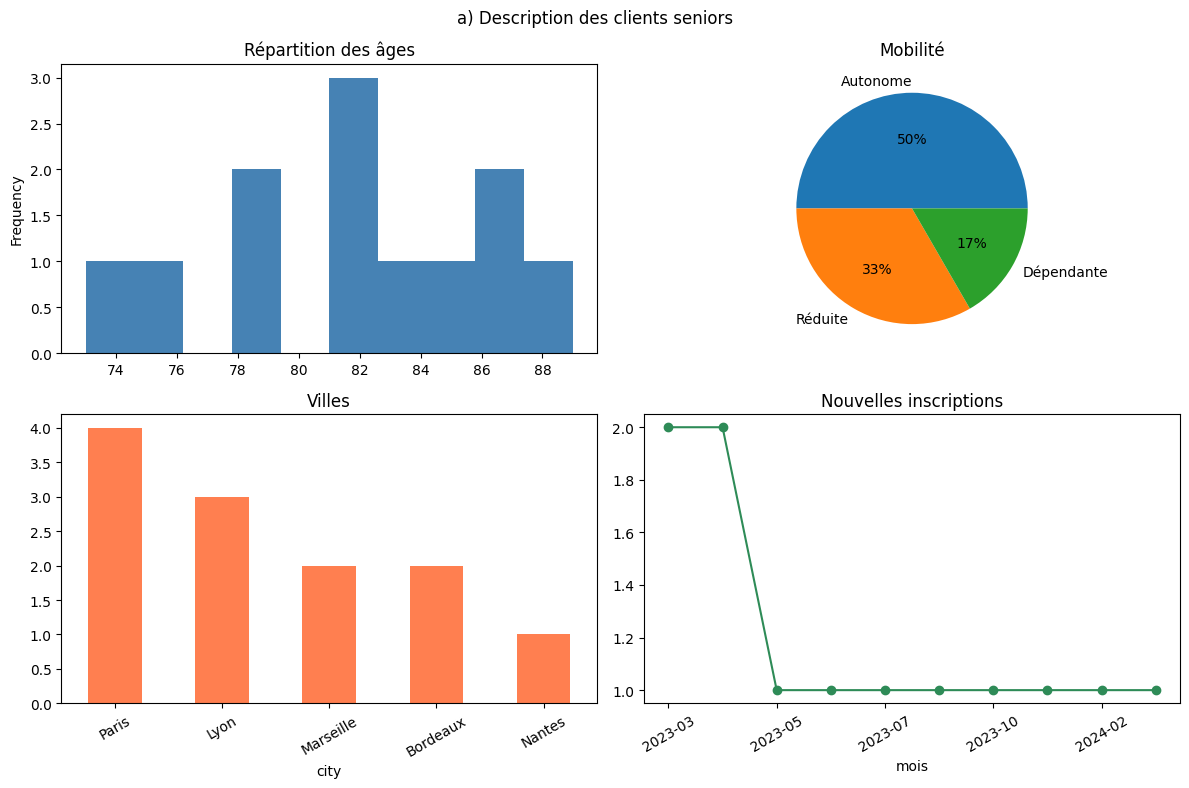

In [ ]:
from datetime import date

rng2 = np.random.default_rng(10)
clients = pd.DataFrame({
    'age':      rng2.integers(65, 95, 80),
    'mobility': rng2.choice(['Autonome', 'Réduite', 'Dépendante'], 80),
    'city':     rng2.choice(['Paris', 'Lyon', 'Marseille', 'Bordeaux', 'Nantes'], 80),
    'mois':     pd.period_range('2023-01', periods=80, freq='W').astype(str),
}) if USE_SAMPLE else query("SELECT birth_date, mobility, city, created_at FROM users WHERE role='senior'").assign(
    age=lambda d: pd.to_datetime(d['birth_date'], errors='coerce').apply(lambda x: (date.today() - x.date()).days // 365 if pd.notna(x) else None),
    mois=lambda d: pd.to_datetime(d['created_at'], errors='coerce').dt.to_period('M').astype(str)
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
clients['age'].dropna().plot.hist(bins=10, ax=axes[0,0], color='steelblue', title='Âges')
clients['mobility'].value_counts().plot.pie(ax=axes[0,1], autopct='%1.0f%%', title='Mobilité')
axes[0,1].set_ylabel('')
clients['city'].value_counts().plot.bar(ax=axes[1,0], color='coral', title='Villes')
clients.groupby('mois').size().tail(12).plot(ax=axes[1,1], marker='o', color='seagreen', title='Inscriptions')
plt.tight_layout(); plt.show()